In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

In [3]:
X, y = make_moons(100, noise=0.25,random_state=2)

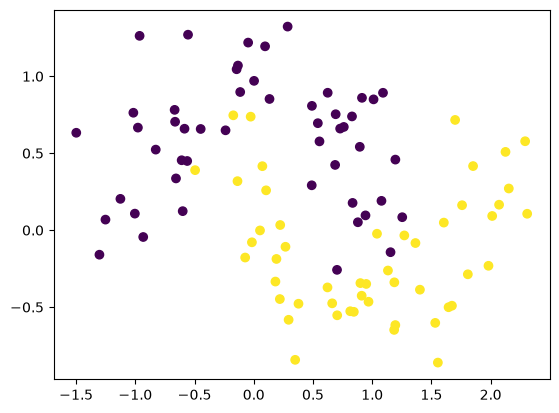

In [4]:
plt.scatter(X[:,0], X[:,1], c=y)
plt.show()

In [5]:
import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam

In [6]:
model1 = Sequential()

model1.add(Dense(128,input_dim=2, activation="relu"))
model1.add(Dense(128, activation="relu"))
model1.add(Dense(1,activation='sigmoid'))

model1.summary()

C:\Users\poona\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
adam = Adam(learning_rate=0.01)
model1.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

history1 = model1.fit(X, y, epochs=2000, validation_split = 0.2,verbose=0)

In [10]:
print("X:", X.shape, X.dtype)
print("y:", y.shape, y.dtype)

pred = model1.predict(X)

print("Prediction:", pred.shape, pred.dtype)
print("Prediction sample:", pred[:10])

X: (100, 2) float64
y: (100,) int64
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Prediction: (100, 1) float32
Prediction sample: [[9.9994904e-01]
 [0.0000000e+00]
 [1.0000000e+00]
 [3.9702685e-23]
 [3.6353166e-13]
 [6.8125475e-15]
 [3.0427075e-06]
 [2.2673735e-16]
 [2.9843404e-06]
 [2.0763391e-11]]


In [11]:
class MyModel:
    def predict(self, X):
        return (model1.predict(X, verbose=0) > 0.5).astype(int).ravel()

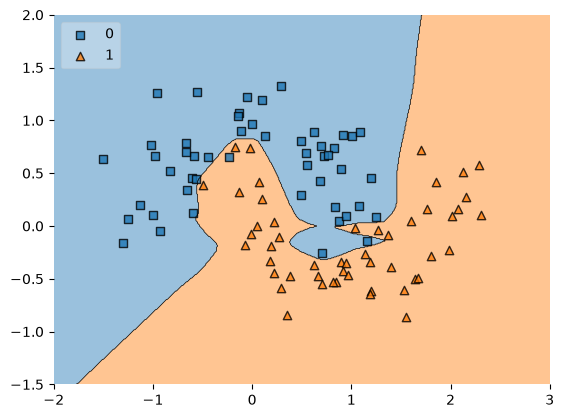

In [12]:
clf = MyModel()

plot_decision_regions(X, y, clf=clf, legend=2)

plt.xlim(-2, 3)
plt.ylim(-1.5, 2)
plt.show()

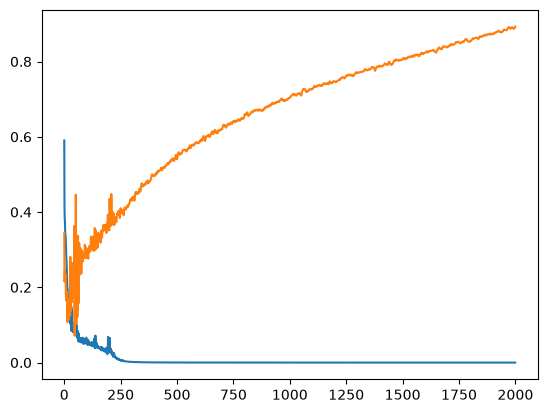

In [13]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])

In [14]:
# Regularization
model2 = Sequential()

model2.add(Dense(128,input_dim=2, activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l1(0.001)))
model2.add(Dense(128, activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l1(0.001)))
model2.add(Dense(1,activation='sigmoid'))

model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
adam = Adam(learning_rate=0.01)
model2.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

history2 = model2.fit(X, y, epochs=2000, validation_split = 0.2,verbose=0)

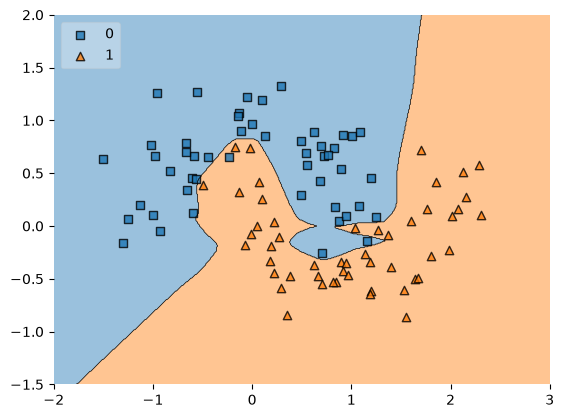

In [18]:
clf = MyModel()
plot_decision_regions(X, y, clf=clf, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

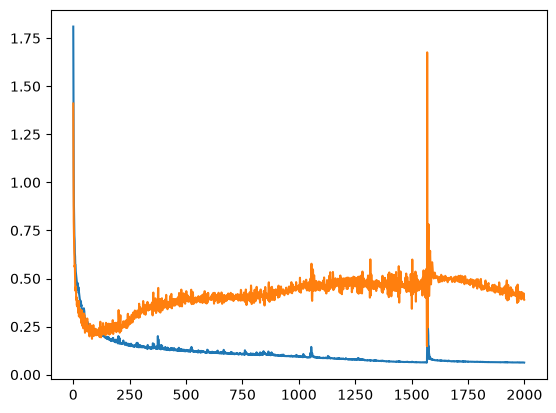

In [19]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])

In [20]:
model1_weight_layer1 = model1.get_weights()[0].reshape(256)
model2_weight_layer1 = model2.get_weights()[0].reshape(256)

<Axes: >

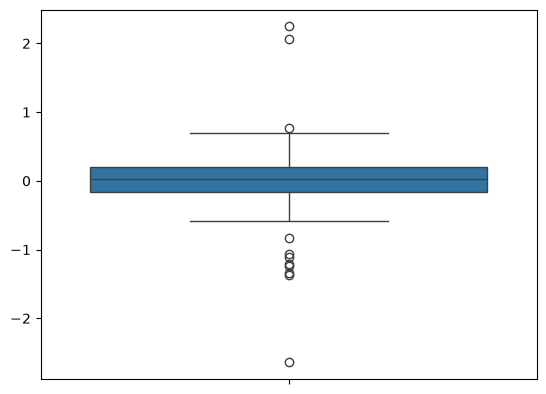

In [21]:
sns.boxplot(model1_weight_layer1)

<Axes: >

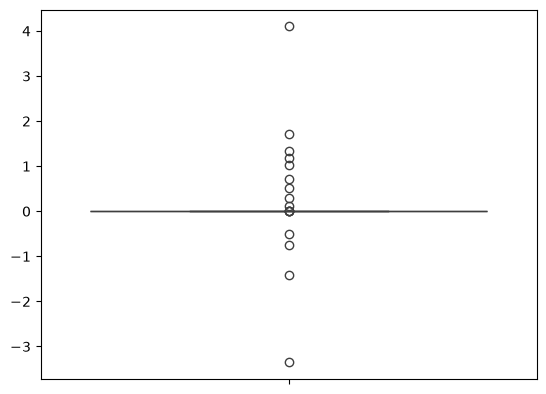

In [22]:
sns.boxplot(model2_weight_layer1)

In [23]:
model1_weight_layer1.min()

np.float32(-2.6410227)

In [24]:
model2_weight_layer1.min()

np.float32(-3.3516588)

C:\Users\poona\AppData\Local\Temp\ipykernel_11752\2224180084.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(model1_weight_layer1)
C:\Users\poona\AppData\Local\Temp\ipykernel_11752\2224180084.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(model2_weight_layer1)


<Axes: ylabel='Density'>

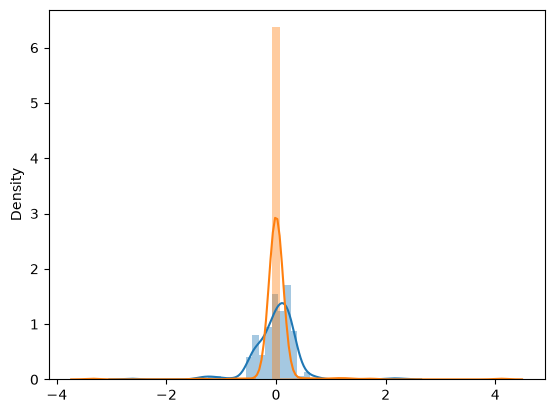

In [25]:
sns.distplot(model1_weight_layer1)
sns.distplot(model2_weight_layer1)

In [26]:
model1.get_weights()[0].reshape(256)

array([-2.50838339e-01, -3.69017601e-01, -1.55708790e-01,  3.14306691e-02,
       -3.86011869e-01, -1.96631908e-01, -2.29350217e-02,  3.00318897e-01,
        3.46428573e-01, -3.29840064e-01,  1.09501682e-01, -7.23156407e-02,
        2.33089134e-01, -3.26903820e-01, -1.40371248e-01,  1.35862321e-01,
       -4.19989154e-02,  3.44502658e-01,  8.00177827e-02, -4.22115356e-01,
       -2.23150387e-01, -4.31348681e-01, -3.03494751e-01,  9.37676877e-02,
       -9.71227512e-03,  4.05458212e-01,  2.38435984e-01,  1.99138060e-01,
       -2.02449217e-01,  2.84269333e-01,  3.06780189e-01,  2.75955081e-01,
       -4.34116632e-01,  3.38250279e-01, -3.73377293e-01,  2.21381083e-01,
       -2.72396445e-01,  4.25450914e-02, -4.36305314e-01,  2.14046851e-01,
       -1.21024102e-01, -3.86879921e-01,  2.43635848e-02, -1.07876351e-02,
       -1.69841468e-01, -4.07118857e-01, -3.90888214e-01, -4.79512274e-01,
       -6.66910037e-02, -2.49731869e-01, -3.77467304e-01, -3.52014869e-01,
        3.49729270e-01,  